## Read Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

/var/folders/69/_jw_j6yj01b559dqr0mh0njm0000gn/T/ipykernel_74462/208474226.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [3]:
data = pd.read_csv('trajectories.csv')
print(data.head())

  Type   Longitude   Latitude         R        Date  Track
0   AC  169.541667  31.013889  0.423142  2013-01-01  10286
1   AC  169.531250  31.062500  0.398942  2013-01-02  10286
2   AC  169.450000  31.050000  0.446031  2013-01-03  10286
3   AC  169.402778  31.041667  0.423142  2013-01-04  10286
4   AC  169.375000  31.062500  0.398942  2013-01-05  10286


In [4]:
ac_area_list = np.load('ac_area.npy')
c_area_list = np.load('c_area.npy')

maplon = np.load('maplon.npy')
maplat = np.load('maplat.npy')

(28.0, 40.0)

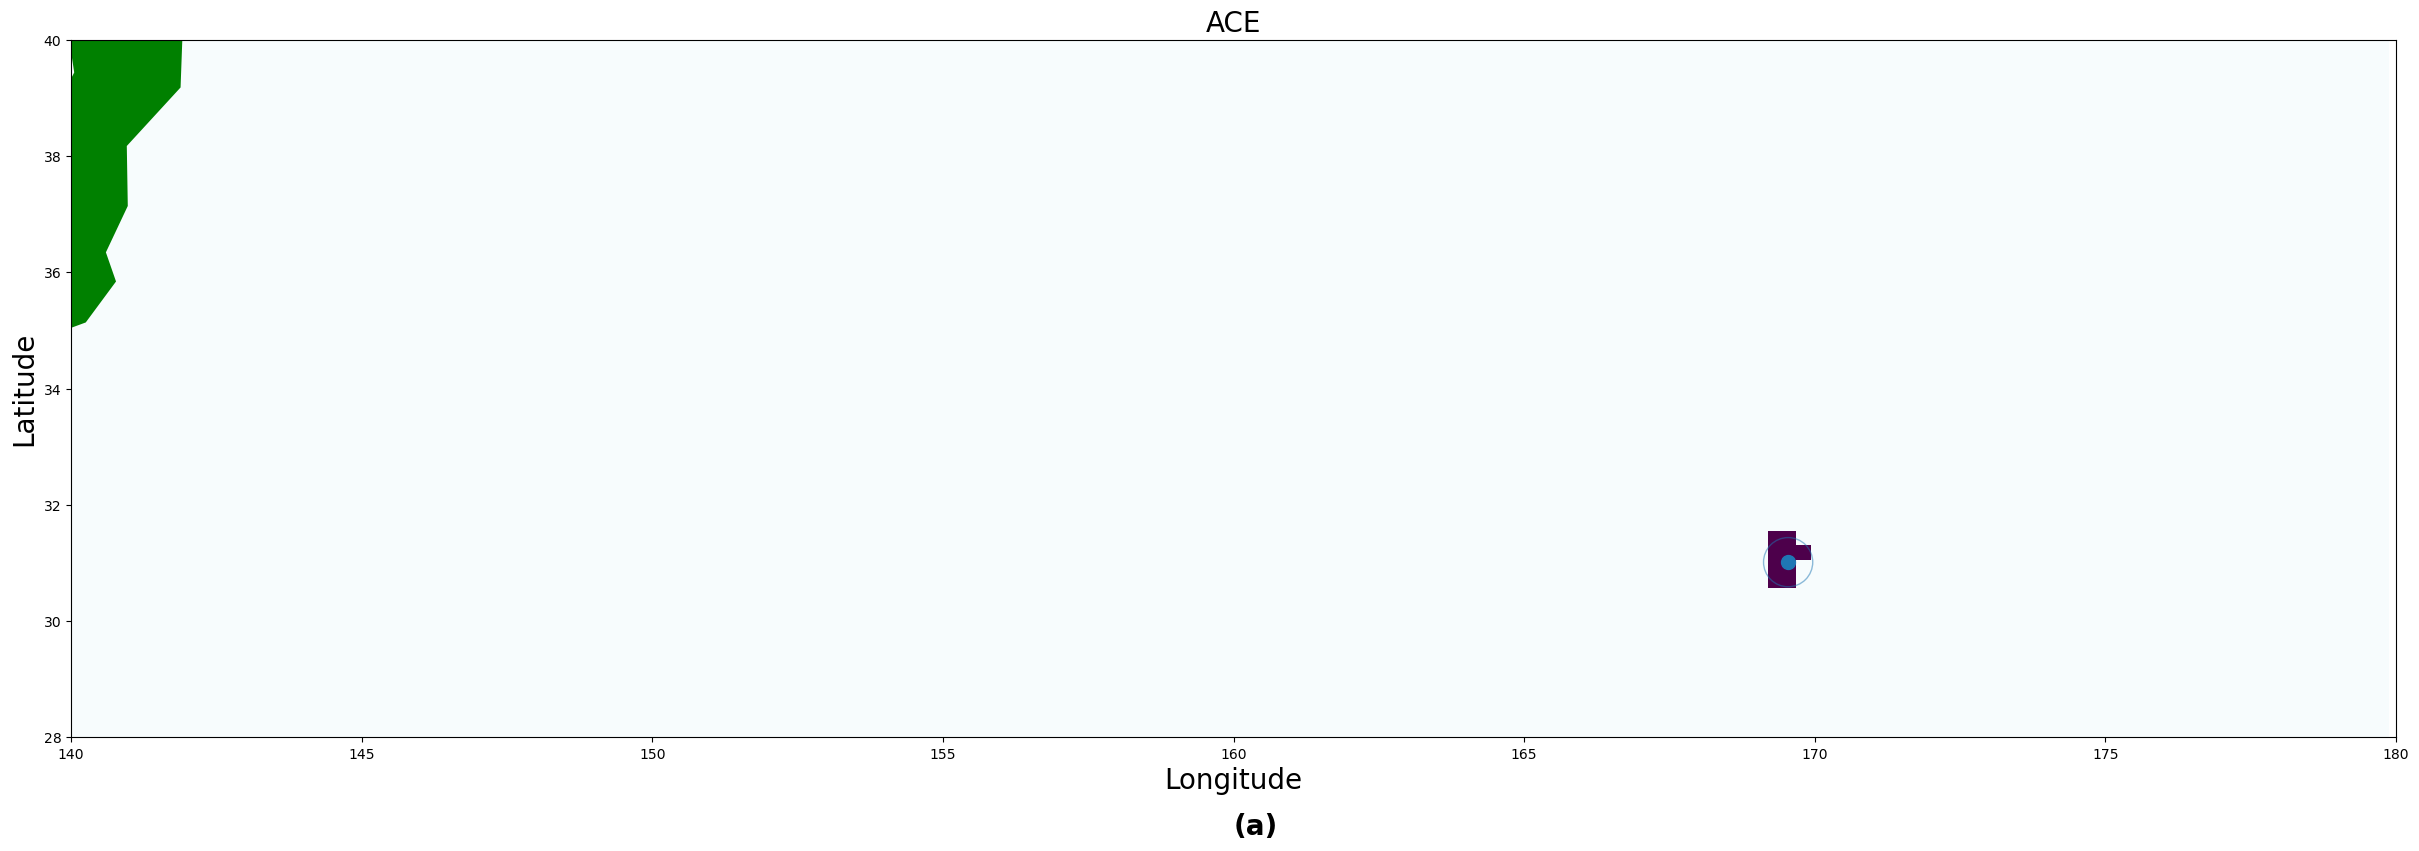

In [5]:
num=0

fig, ax = plt.subplots(figsize=(30, 20))
ax.set_title('ACE', fontsize=20)
ax.set_xlabel('Longitude', fontsize=20)
ax.set_ylabel('Latitude', fontsize=20)
ax.text(0.5, -0.14, '(a)', transform=ax.transAxes, size=20, weight='bold')
world.plot(color='green', ax=ax)
ax.scatter(data.iloc[num]['Longitude'], data.iloc[num]['Latitude'], color=colors[0], s=100, label='Point')
circle = plt.Circle((data.iloc[num]['Longitude'], data.iloc[num]['Latitude']), data.iloc[num]['R'], color=colors[0], fill=False, alpha=0.5)
ax.add_patch(circle)
img=ax.imshow(ac_area_list[num],extent=[maplon.min(), maplon.max(), maplat.min(), maplat.max()], cmap='BuPu')
ax.set_xlim([140, 180])
ax.set_ylim([28, 40])